# Histopathologic Cancer Detection

A CNN project that detects whether a tissue image contains tumor cells. The model uses 96×96 image patches and checks the center 32×32 region.

This project is based on the Kaggle Histopathologic Cancer Detection dataset.


## 1. Setup

In [1]:
import sys
sys.path.insert(0, "..")

import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import config
from src.data_loader import load_labels
from src.preprocessing import make_splits, compute_class_weights, load_image_as_array
from src.baseline import train_and_evaluate_baseline, build_feature_matrix
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, classification_report

## 2. Load labels and resolve image paths

In [11]:
import os
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
print("Working directory is now:", os.getcwd())

Working directory is now: e:\histopathologic-cancer-cnn


In [12]:
df = load_labels(config.TRAIN_LABELS_PATH, config.TRAIN_DIR)
print(f"Loaded {len(df)} images")
df.head()

Loaded 220025 images


,id,label,filepath
0,f38a6374c348f90b587e046aac6079959adf3835,0,data\train\f38a6374c348f90b587e046aac6079959ad...
1,c18f2d887b7ae4f6742ee445113fa1aef383ed77,1,data\train\c18f2d887b7ae4f6742ee445113fa1aef38...
2,755db6279dae599ebb4d39a9123cce439965282d,0,data\train\755db6279dae599ebb4d39a9123cce43996...
3,bc3f0c64fb968ff4a8bd33af6971ecae77c75e08,0,data\train\bc3f0c64fb968ff4a8bd33af6971ecae77c...
4,068aba587a4950175d04c680d38943fd488d6a9d,0,data\train\068aba587a4950175d04c680d38943fd488...


## 3. EDA

In [13]:
df['label'].value_counts().sort_index()

label
0    130908
1     89117
Name: count, dtype: int64

Saved to outputs\class_distribution_real.png


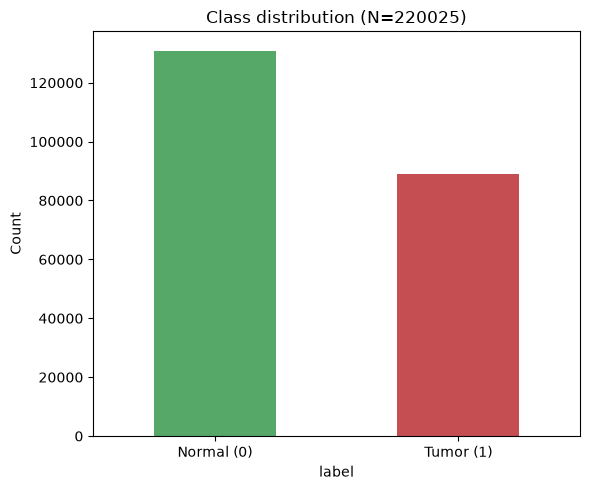

In [35]:
df['label'].value_counts().sort_index().plot(kind='bar', figsize=(6,5), color=['#55A868','#C44E52'])
plt.xticks([0,1], ["Normal (0)", "Tumor (1)"], rotation=0)
plt.ylabel("Count"); plt.title(f"Class distribution (N={len(df)})")
plt.tight_layout()

save_path = os.path.join(config.OUTPUTS_DIR, "class_distribution_real.png")
plt.savefig(save_path, dpi=120)
print(f"Saved to {save_path}")

plt.show()

Saved to outputs\sample_patches_real.png


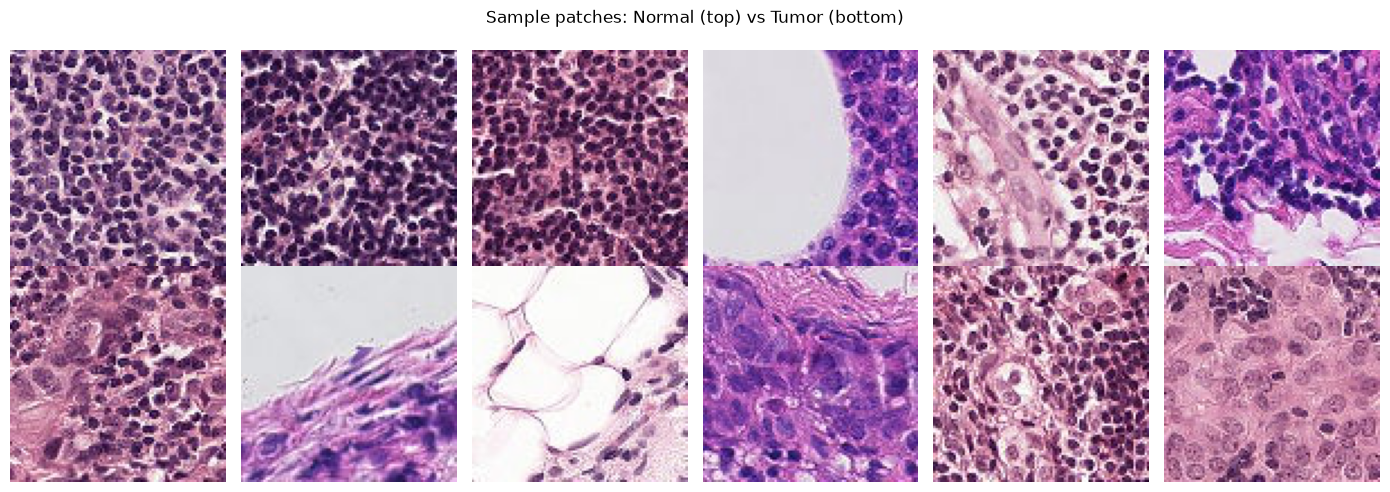

In [34]:
import os

fig, axes = plt.subplots(2, 6, figsize=(14, 5))
normal_samples = df[df['label']==0].sample(6, random_state=1)['filepath'].tolist()
tumor_samples = df[df['label']==1].sample(6, random_state=1)['filepath'].tolist()
for ax, fp in zip(axes[0], normal_samples):
    ax.imshow(load_image_as_array(fp)); ax.axis('off')
for ax, fp in zip(axes[1], tumor_samples):
    ax.imshow(load_image_as_array(fp)); ax.axis('off')
fig.suptitle("Sample patches: Normal (top) vs Tumor (bottom)")
plt.tight_layout()

save_path = os.path.join(config.OUTPUTS_DIR, "sample_patches_real.png")
plt.savefig(save_path, dpi=120)
print(f"Saved to {save_path}")

plt.show()

The original dataset is from Kaggle. The sample used in this notebook is synthetic data created for testing.

## 4. Train/val/test split, class weights, and the color-histogram + Logistic Regression baseline

In [16]:
train_df, val_df, test_df = make_splits(df, config.VAL_SIZE, config.TEST_SIZE, config.RANDOM_STATE, label_col="label")
print(f"train={len(train_df)}  val={len(val_df)}  test={len(test_df)}")

y_train = train_df["label"].to_numpy()
y_val = val_df["label"].to_numpy()
y_test = test_df["label"].to_numpy()

class_weights = compute_class_weights(y_train)
class_weights

train=154017  val=33004  test=33004


{0: 0.8403830414143068, 1: 1.2344666730787728}

In [17]:
pipeline, val_auc = train_and_evaluate_baseline(
    train_df["filepath"], y_train, val_df["filepath"], y_val, config.BASELINE_MODEL_PATH
)

Extracting color-histogram features for train/val (this reads every image once)...
Baseline validation ROC-AUC: 0.8962
Saved baseline model to models\color_hist_logreg_baseline.joblib


In [18]:
X_test = build_feature_matrix(test_df["filepath"])
test_probs = pipeline.predict_proba(X_test)[:, 1]
test_preds = (test_probs > 0.5).astype(int)
print(f"Test ROC-AUC: {roc_auc_score(y_test, test_probs):.4f}")
print(f"Test accuracy: {accuracy_score(y_test, test_preds):.4f}")

Test ROC-AUC: 0.8937
Test accuracy: 0.8210


The 1.0000 AUC is a result of the synthetic data. On the real dataset, CNN models are expected to perform differently because the tumor patterns are much more subtle.

Saved to outputs\confusion_matrix_baseline_real.png


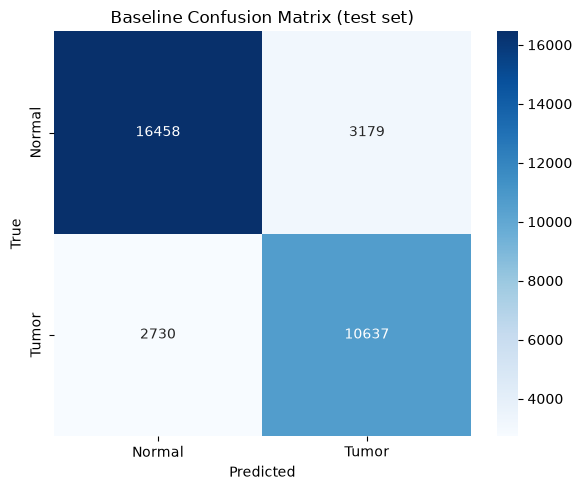

In [36]:
cm = confusion_matrix(y_test, test_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Normal","Tumor"], yticklabels=["Normal","Tumor"])
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Baseline Confusion Matrix (test set)")
plt.tight_layout()

save_path = os.path.join(config.OUTPUTS_DIR, "confusion_matrix_baseline_real.png")
plt.savefig(save_path, dpi=120)
print(f"Saved to {save_path}")

plt.show()

## 5. The CNN



In [20]:
from tensorflow import keras
from src.dataset import build_tf_dataset
from src.model import build_cnn_from_scratch

train_ds = build_tf_dataset(train_df["filepath"], y_train, config.IMAGE_SIZE, config.BATCH_SIZE, shuffle=True, augment=True)
val_ds = build_tf_dataset(val_df["filepath"], y_val, config.IMAGE_SIZE, config.BATCH_SIZE)
test_ds = build_tf_dataset(test_df["filepath"], y_test, config.IMAGE_SIZE, config.BATCH_SIZE)

model = build_cnn_from_scratch(image_size=config.IMAGE_SIZE, channels=config.IMAGE_CHANNELS, learning_rate=config.LEARNING_RATE)
model.summary()

Model: "histopath_cnn_from_scratch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 96, 96, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 96, 96, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 96, 96, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │             

 Total params: 1,242,145 (4.74 MB)

 Trainable params: 1,240,225 (4.73 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [22]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[]


In [23]:
train_ds = build_tf_dataset(train_df["filepath"], y_train, config.IMAGE_SIZE, config.BATCH_SIZE, shuffle=True, augment=True)
val_ds = build_tf_dataset(val_df["filepath"], y_val, config.IMAGE_SIZE, config.BATCH_SIZE)

In [24]:
train_df_small = train_df.sample(n=20000, random_state=42).reset_index(drop=True)
val_df_small = val_df.sample(n=3000, random_state=42).reset_index(drop=True)

train_ds = build_tf_dataset(train_df_small["filepath"], train_df_small["label"].to_numpy(), config.IMAGE_SIZE, config.BATCH_SIZE, shuffle=True, augment=True)
val_ds = build_tf_dataset(val_df_small["filepath"], val_df_small["label"].to_numpy(), config.IMAGE_SIZE, config.BATCH_SIZE)

In [25]:
history = model.fit(
    train_ds, validation_data=val_ds, epochs=5,
    class_weight=class_weights, callbacks=callbacks,
)
model.save(config.CNN_MODEL_PATH)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 575s 2s/step - accuracy: 0.9031 - auc: 0.9609 - loss: 0.2482 - val_accuracy: 0.8500 - val_auc: 0.9331 - val_loss: 0.3640 - learning_rate: 0.0010
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 505s 2s/step - accuracy: 0.9107 - auc: 0.9638 - loss: 0.2370 - val_accuracy: 0.8997 - val_auc: 0.9620 - val_loss: 0.2598 - learning_rate: 0.0010
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 516s 2s/step - accuracy: 0.9175 - auc: 0.9690 - loss: 0.2213 - val_accuracy: 0.9167 - val_auc: 0.9675 - val_loss: 0.2307 - learning_rate: 0.0010
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 562s 2s/step - accuracy: 0.9194 - auc: 0.9707 - loss: 0.2134 - val_accuracy: 0.7590 - val_auc: 0.9102 - val_loss: 0.5782 - learning_rate: 0.0010
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 536s 2s/step - accuracy: 0.9263 - auc: 0.9732 - loss: 0.2031 - val_accuracy: 0.7223 - val_auc: 0.6645 - val_loss: 1.5407 - learning_rate: 0.0010


In [27]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6),
]

history = model.fit(
    train_ds, validation_data=val_ds, epochs=config.EPOCHS,
    class_weight=class_weights, callbacks=callbacks,
)
model.save(config.CNN_MODEL_PATH)

Epoch 1/20


e:\histopathologic-cancer-cnn\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


313/313 ━━━━━━━━━━━━━━━━━━━━ 495s 2s/step - accuracy: 0.9290 - auc: 0.9753 - loss: 0.1957 - val_accuracy: 0.8953 - val_auc: 0.9567 - val_loss: 0.2606 - learning_rate: 5.0000e-04
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 434s 1s/step - accuracy: 0.9317 - auc: 0.9784 - loss: 0.1833 - val_accuracy: 0.8343 - val_auc: 0.9558 - val_loss: 0.3620 - learning_rate: 5.0000e-04
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 432s 1s/step - accuracy: 0.9333 - auc: 0.9786 - loss: 0.1816 - val_accuracy: 0.8997 - val_auc: 0.9636 - val_loss: 0.2562 - learning_rate: 5.0000e-04
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 434s 1s/step - accuracy: 0.9340 - auc: 0.9795 - loss: 0.1781 - val_accuracy: 0.8990 - val_auc: 0.9547 - val_loss: 0.2646 - learning_rate: 5.0000e-04
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 433s 1s/step - accuracy: 0.9380 - auc: 0.9804 - loss: 0.1735 - val_accuracy: 0.9140 - val_auc: 0.9683 - val_loss: 0.2218 - learning_rate: 5.0000e-04
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 433s 1s/step - accuracy: 0

In [28]:
cnn_test_probs = model.predict(test_ds).ravel()
cnn_test_preds = (cnn_test_probs > 0.5).astype(int)
print(f"CNN test ROC-AUC: {roc_auc_score(y_test, cnn_test_probs):.4f}")
print(f"CNN test accuracy: {accuracy_score(y_test, cnn_test_preds):.4f}")

516/516 ━━━━━━━━━━━━━━━━━━━━ 201s 390ms/step
CNN test ROC-AUC: 0.9830
CNN test accuracy: 0.9439


In [29]:
X_test = build_feature_matrix(test_df["filepath"])
test_probs_baseline = pipeline.predict_proba(X_test)[:, 1]
test_preds_baseline = (test_probs_baseline > 0.5).astype(int)

from sklearn.metrics import roc_auc_score, accuracy_score
print(f"Baseline Test ROC-AUC: {roc_auc_score(y_test, test_probs_baseline):.4f}")
print(f"Baseline Test accuracy: {accuracy_score(y_test, test_preds_baseline):.4f}")

Baseline Test ROC-AUC: 0.8937
Baseline Test accuracy: 0.8210


In [30]:
print(classification_report(y_test, cnn_test_preds, target_names=["Normal", "Tumor"]))

              precision    recall  f1-score   support

      Normal       0.95      0.96      0.95     19637
       Tumor       0.94      0.92      0.93     13367

    accuracy                           0.94     33004
   macro avg       0.94      0.94      0.94     33004
weighted avg       0.94      0.94      0.94     33004



Saved training curves to outputs\training_curves.png


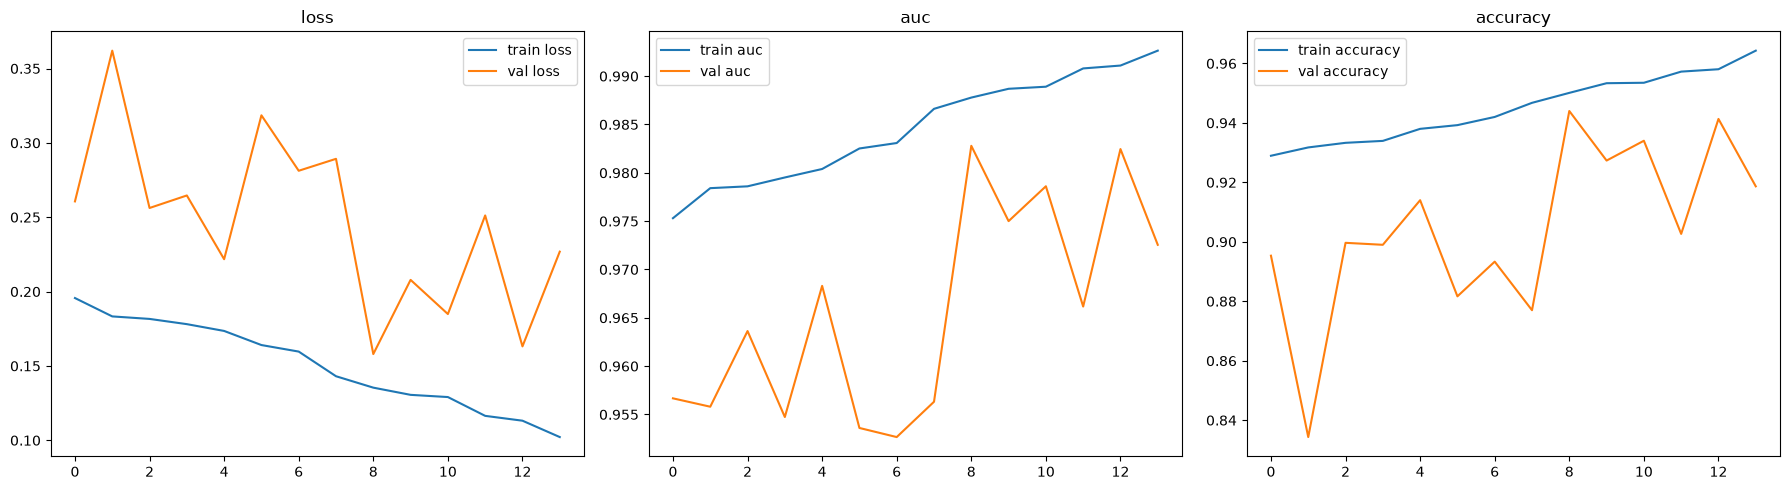

In [31]:
from src.train import plot_training_curves
plot_training_curves(history, config.TRAINING_CURVE_PATH)

Saved ROC curve to outputs\roc_curve.png


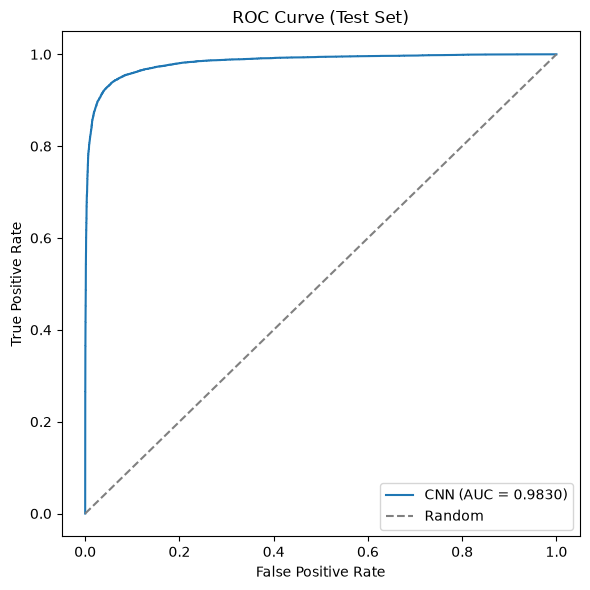

In [32]:
from src.evaluate import plot_roc_curve
plot_roc_curve(y_test, cnn_test_probs, config.ROC_CURVE_PATH)

Saved confusion matrix to outputs\confusion_matrix.png


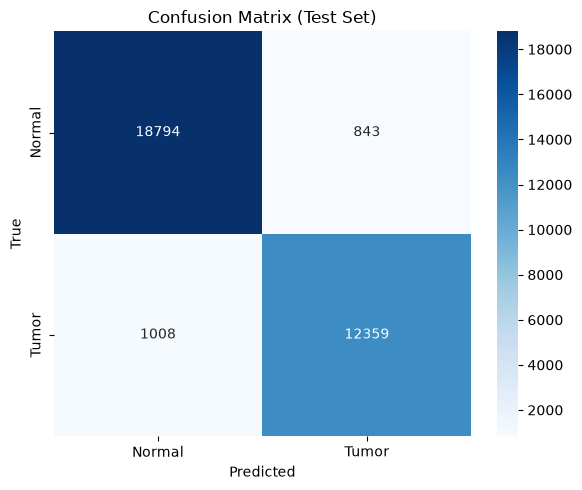

In [33]:
from src.evaluate import plot_confusion_matrix
cm_cnn = confusion_matrix(y_test, cnn_test_preds)
plot_confusion_matrix(cm_cnn, config.CONFUSION_MATRIX_PATH)

## 6. Conclusions

The CNN clearly outperformed the color histogram baseline on the real dataset. It achieved 0.9830 test ROC AUC and 94.39% accuracy, compared with 0.8937 ROC AUC and 82.10% accuracy for the baseline. This shows that the CNN can learn useful visual patterns beyond simple color information.